# 15. 제출 보고서용 그림

> **이 노트북은 새 분석을 하지 않는다.** 이미 확정된 산출물(`output/*.csv`)과 마스터 테이블을
> 그림으로 옮기기만 한다. 판정·채택·제외에 영향을 주는 계산은 한 줄도 없다.
>
> **입력** — `03_master.csv` · `_prewin/02b·02c` · `13j` · `14e` · `14g` · `14j`
> **출력** — `figures/` 폴더에 PNG 7종
>
> 노트북 `01`·`03`·`09`·`10a`·`10b`·`14` 에 이미 있는 그림 8종은 여기서 다시 그리지 않는다.
> 그쪽은 셀 출력 이미지를 그대로 저장해서 쓴다.

In [2]:
# #01. 준비 ─────────────────────────────────────────────
import os

# 프로젝트 폴더 — notebooks/ 안에서 실행하면 상위 폴더를 가리킨다
from pathlib import Path
BASE = str(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd())
OUT   = BASE + r"\output"
FIG   = BASE + r"\docs\figures"
os.makedirs(FIG, exist_ok=True)
os.chdir(BASE)                          # helpers 폰트 경로가 상대경로다

import numpy as np
from pandas import read_csv, to_datetime, DataFrame, qcut
from matplotlib import pyplot as plt
from helpers import my_plot

def save(name):
    """공통 저장 — 여백을 잘라 보고서 삽입 시 가장자리가 뜨지 않게 한다"""
    plt.tight_layout()
    plt.savefig(os.path.join(FIG, name), bbox_inches="tight")
    plt.show()
    plt.close()

m = read_csv(OUT + r"\03_master.csv", encoding="utf-8-sig")
print(f"마스터 {len(m):,}행  |  Y {m['purchase_7d'].mean():.4%}")

마스터 108,458행  |  Y 20.5019%


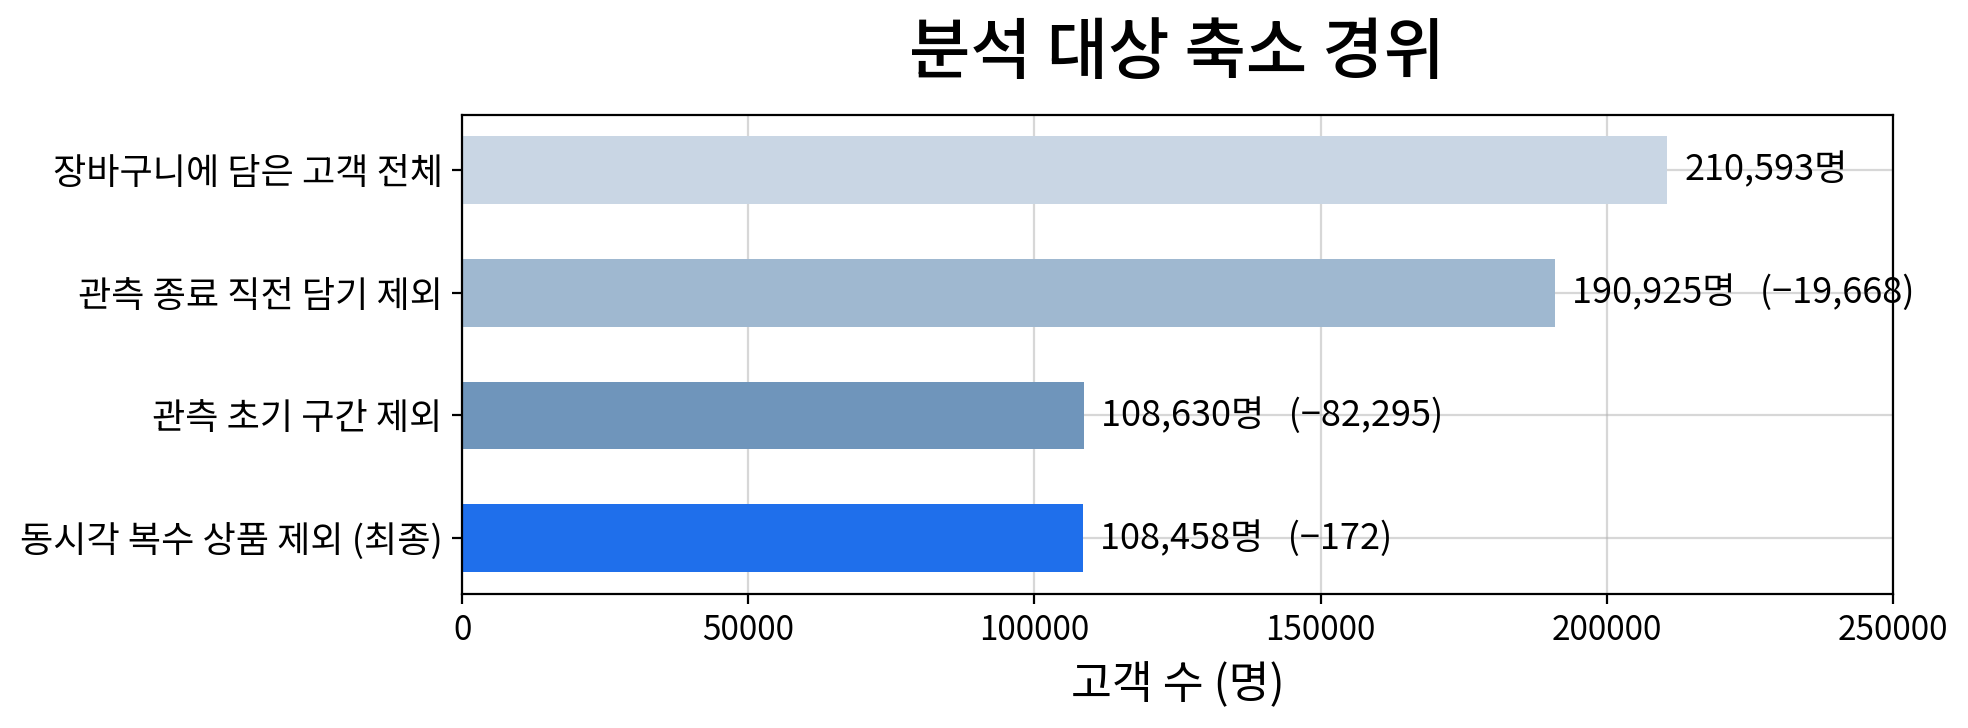

In [3]:
# #02. [그림 1] 분석 대상 축소 흐름 ─────────────────────
#   출처 : 결과 보고서 §3.6 (03번 #02·#04·#05). 상수를 옮겨 적은 것이다.
label = ["장바구니에 담은 고객 전체", "관측 종료 직전 담기 제외",
         "관측 초기 구간 제외", "동시각 복수 상품 제외 (최종)"]
n    = [210593, 190925, 108630, 108458]
drop = [None, 19668, 82295, 172]

fig, ax = my_plot.init(width=1000, height=380,
                       title="분석 대상 축소 경위", xlabel="고객 수 (명)")
pos = np.arange(len(n))[::-1]
bars = ax.barh(pos, n, height=0.55,
               color=["#c9d6e4", "#9fb8d0", "#6f95bb", "#1f6feb"])
for p, v, d in zip(pos, n, drop):
    ax.text(v + 3000, p, f"{v:,}명" + (f"   (−{d:,})" if d else ""),
            va="center", fontsize=13)
ax.set_yticks(pos)
ax.set_yticklabels(label, fontsize=13)
ax.set_xlim(0, 250000)
save("fig01_대상축소.png")

                           n      Y      V
t0                                        
2019-09-30/2019-10-06  55718   7.79  83.58
2019-10-07/2019-10-13  33760  12.30  72.68
2019-10-14/2019-10-20  18026  20.39  55.08
2019-10-21/2019-10-27  16651  20.12  54.73
2019-10-28/2019-11-03  15665  20.34  56.63
2019-11-04/2019-11-10  17202  20.83  55.85
2019-11-11/2019-11-17  15524  19.96  55.62
2019-11-18/2019-11-24  18152  21.50  54.31


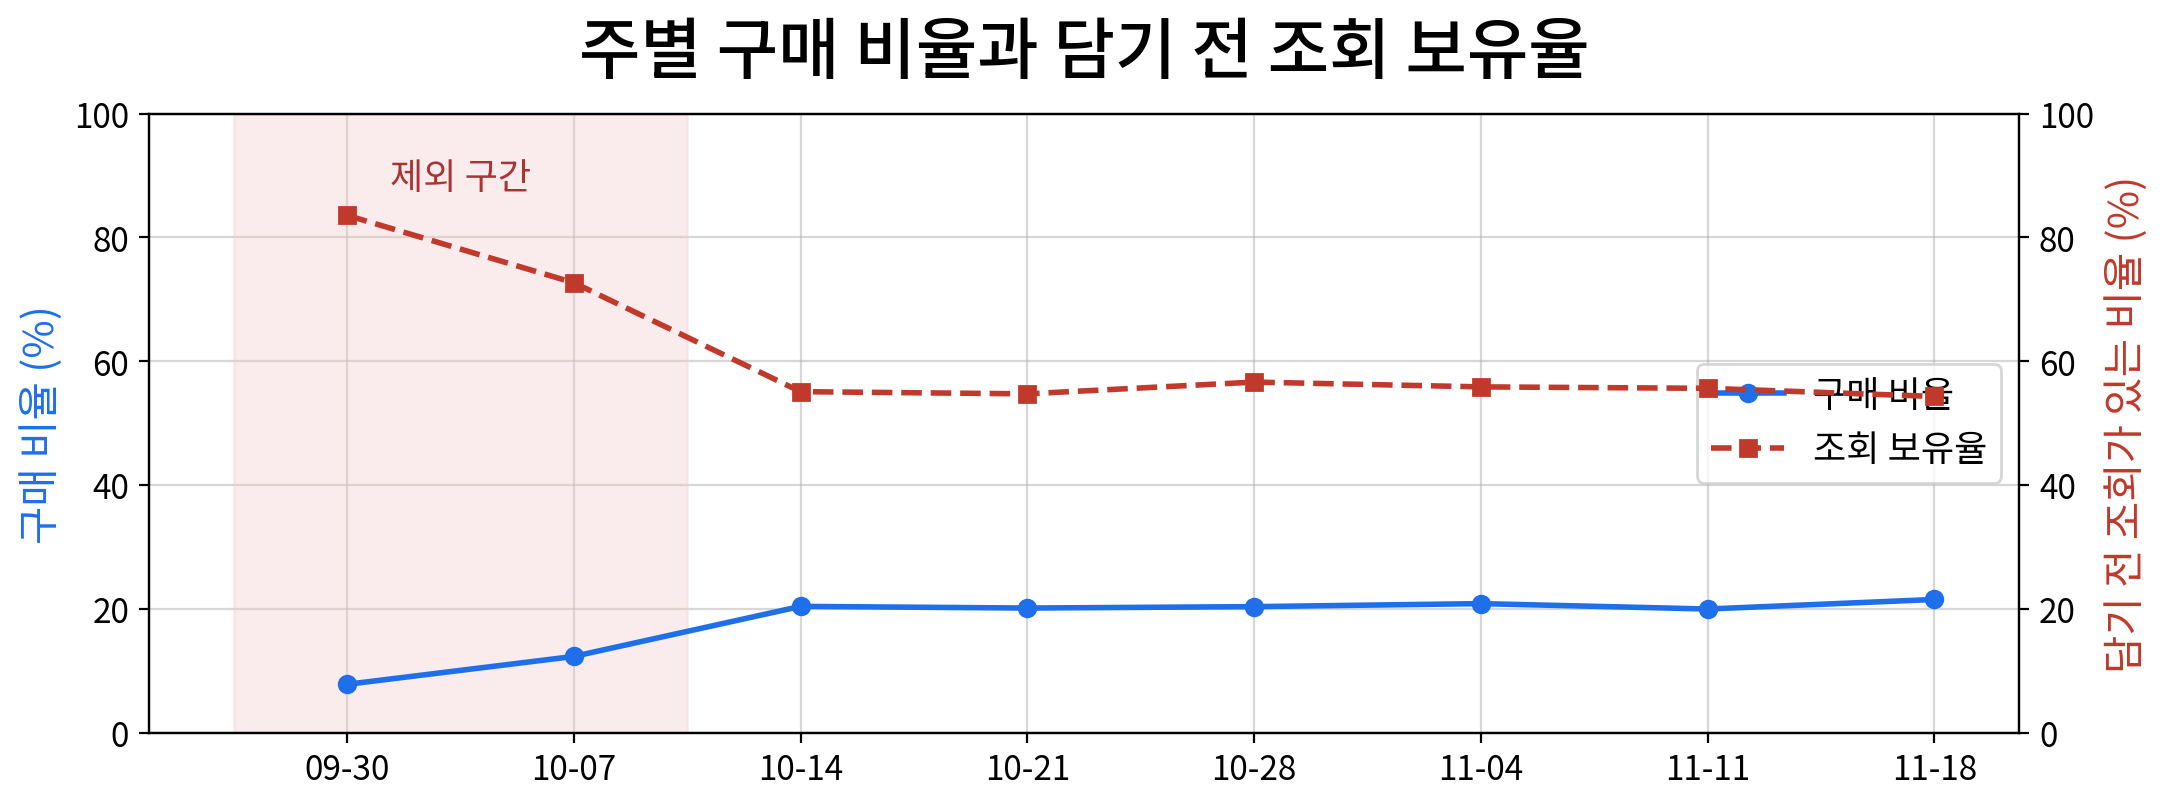

In [4]:
# #03. [그림 2] 주별 구매비율과 조회보유율 ───────────────
#   출처 : 07번 #3 과 같은 계산. 번인 제외의 근거 그림이다.
x = read_csv(OUT + r"\_prewin\02b_x.csv", encoding="utf-8-sig")
y = read_csv(OUT + r"\_prewin\02c_y.csv", encoding="utf-8-sig")
d = x.merge(y[["user_id", "purchase_7d"]], on="user_id", how="inner")
d["t0"] = to_datetime(d["t0"])
assert len(d) == len(x)

g = d.groupby(d["t0"].dt.to_period("W"))
w = DataFrame({"n": g.size(),
               "Y":  g["purchase_7d"].mean() * 100,
               "V":  g["has_prior_view"].mean() * 100})
print(w.round(2))

fig, (axL, axR) = my_plot.init(width=1100, height=420, twinx=True,
                               title="주별 구매 비율과 담기 전 조회 보유율")
t = np.arange(len(w))
axL.axvspan(-0.5, 1.5, color="#f2c9c9", alpha=0.35)          # 제외한 첫 두 주
axL.text(0.5, 88, "제외 구간", ha="center", fontsize=13, color="#a33")
axL.plot(t, w["Y"], marker="o", color="#1f6feb", label="구매 비율")
axR.plot(t, w["V"], marker="s", ls="--", color="#c0392b", label="조회 보유율")
axL.set_xticks(t)
axL.set_xticklabels([p.start_time.strftime("%m-%d") for p in w.index], fontsize=12)
axL.set_ylim(0, 100); axR.set_ylim(0, 100)
axL.set_ylabel("구매 비율 (%)", fontsize=15, color="#1f6feb")
axR.set_ylabel("담기 전 조회가 있는 비율 (%)", fontsize=15, color="#c0392b")
axR.grid(False)
lines = axL.get_lines() + axR.get_lines()
axL.legend(lines, [l.get_label() for l in lines], loc="center right", fontsize=13)
save("fig02_주별_번인근거.png")

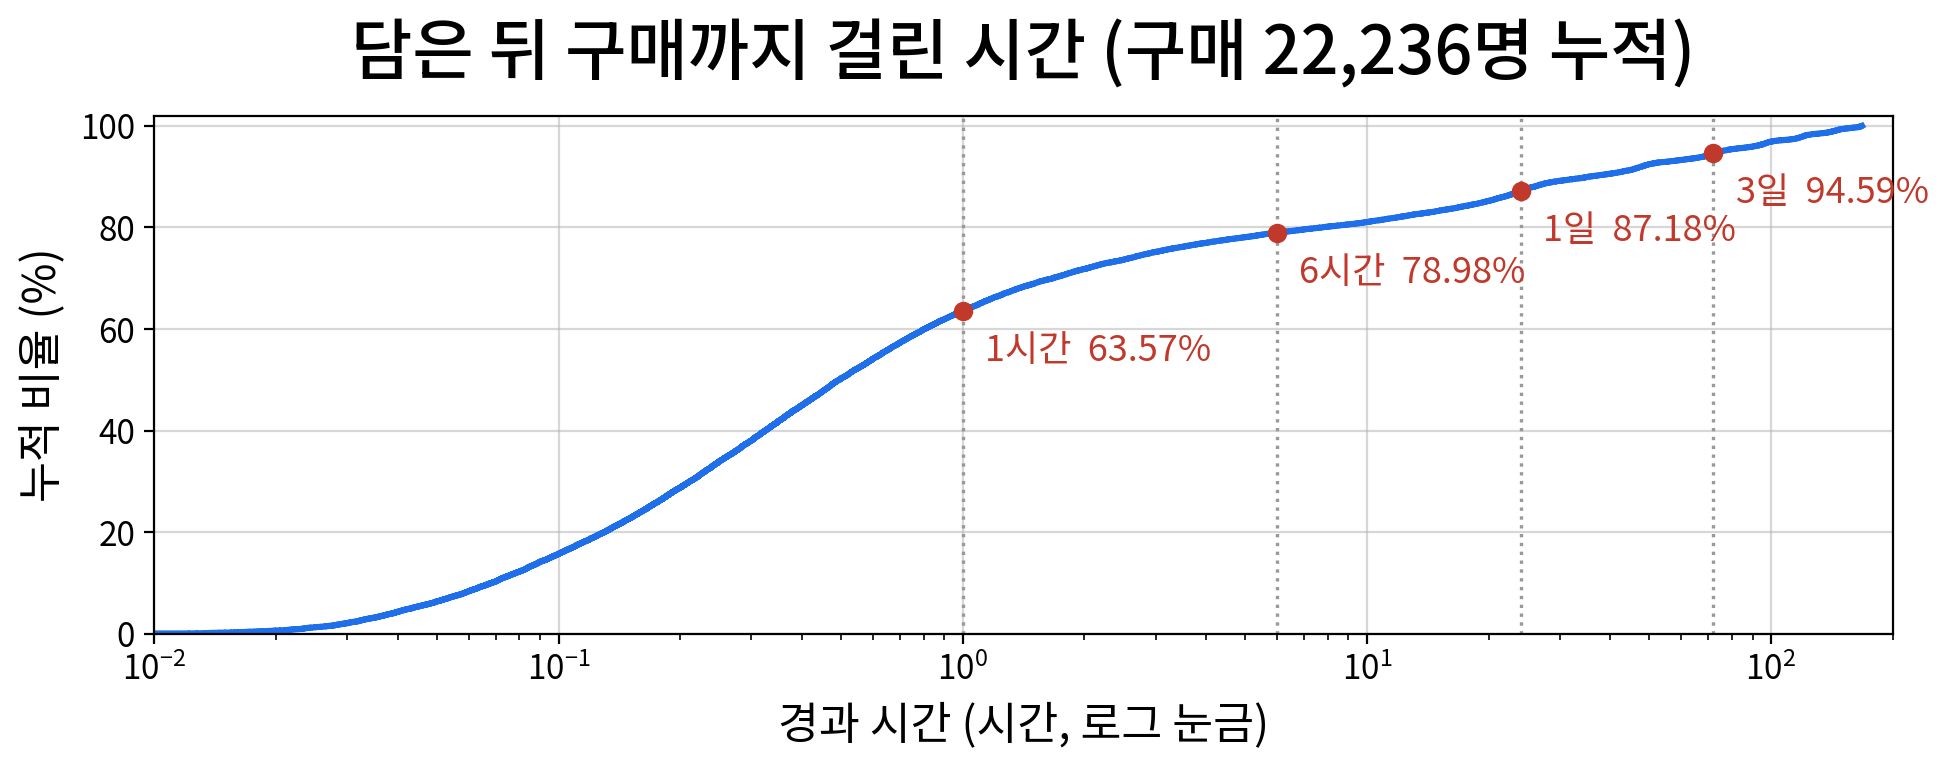

In [5]:
# #04. [그림 3] 담기 → 구매 시차 누적분포 ────────────────
#   출처 : 마스터 테이블 lag_hours (Y=1). 결과 보고서 §3.3 표와 같은 값이다.
lag = m.loc[m["purchase_7d"] == 1, "lag_hours"].dropna().sort_values().to_numpy()
cum = np.arange(1, len(lag) + 1) / len(lag) * 100

fig, ax = my_plot.init(width=1000, height=400,
                       title="담은 뒤 구매까지 걸린 시간 (구매 %s명 누적)" % format(len(lag), ","),
                       xlabel="경과 시간 (시간, 로그 눈금)", ylabel="누적 비율 (%)")
ax.step(lag, cum, where="post", color="#1f6feb", lw=2.2)
for h, name in [(1, "1시간"), (6, "6시간"), (24, "1일"), (72, "3일")]:
    v = (lag <= h).mean() * 100
    ax.axvline(h, color="#999", ls=":", lw=1.2)
    ax.plot([h], [v], "o", color="#c0392b", ms=6)
    ax.annotate(f"{name}  {v:.2f}%", (h, v), textcoords="offset points",
                xytext=(8, -18), fontsize=13, color="#c0392b")
ax.set_xscale("log"); ax.set_xlim(0.01, 200); ax.set_ylim(0, 102)
save("fig03_시차누적.png")

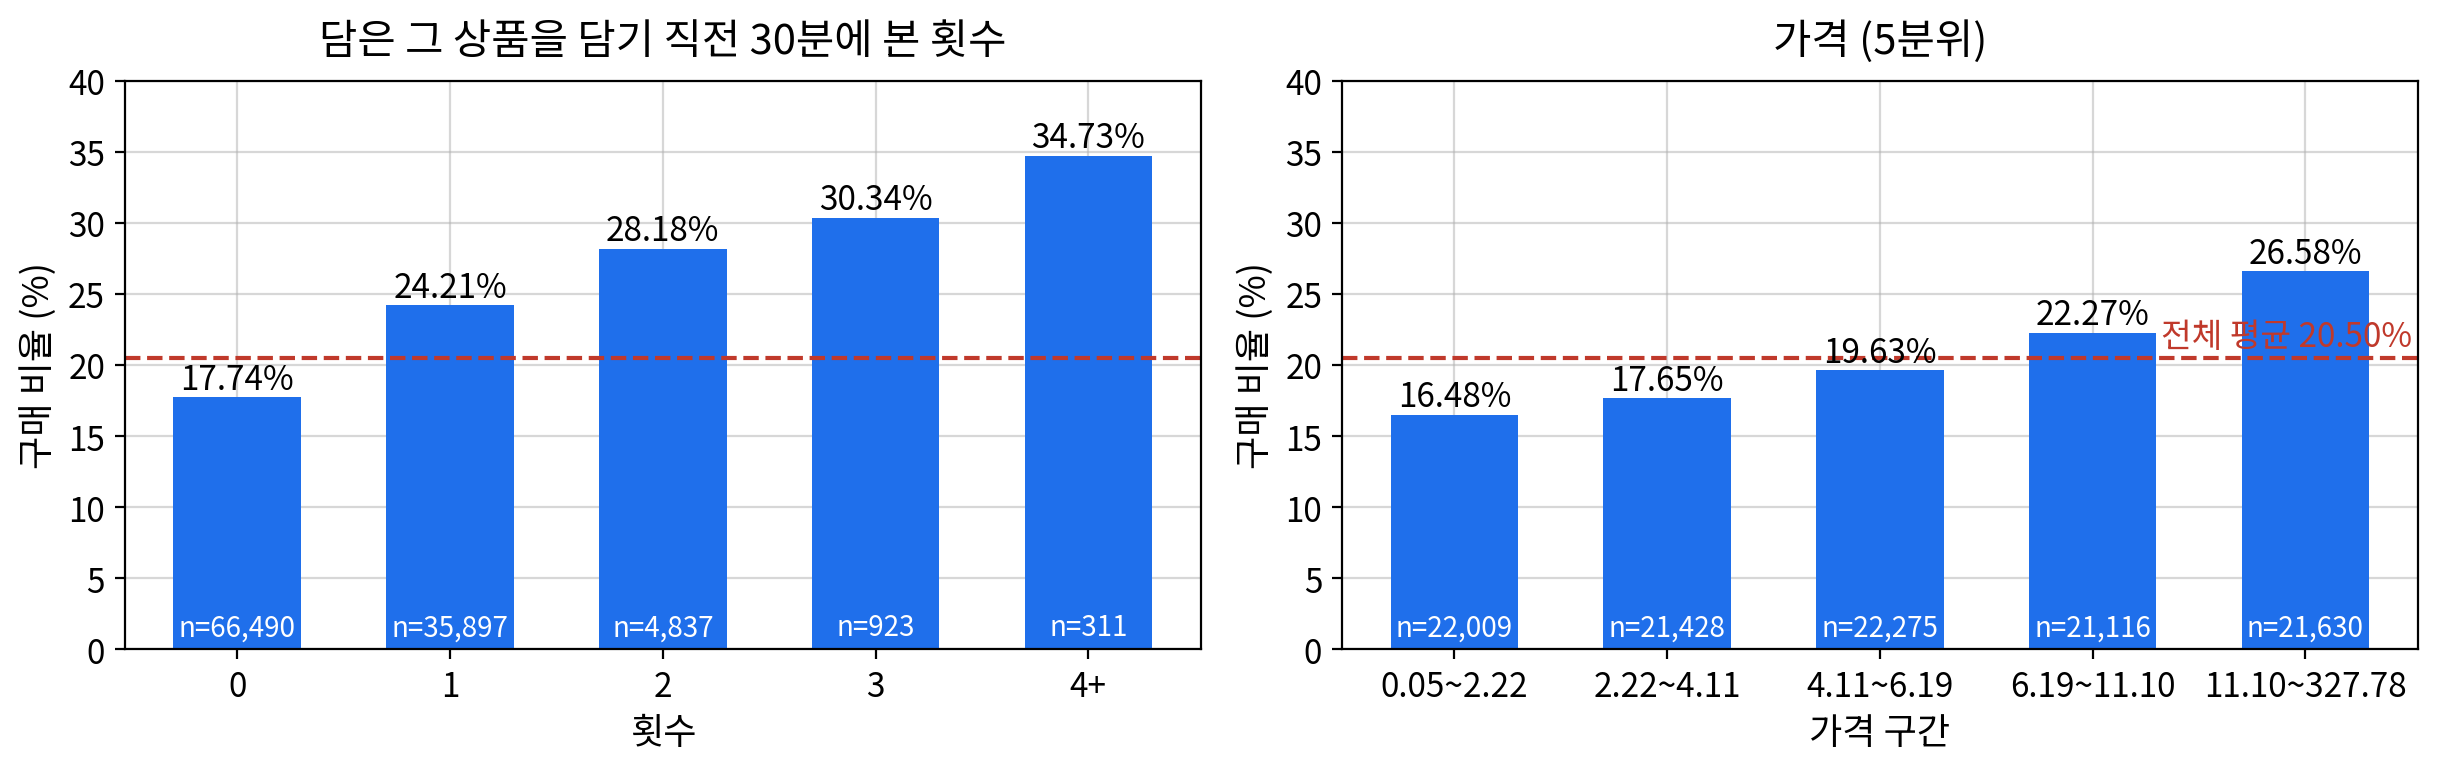

In [6]:
# #05. [그림 4] 구간별 구매 비율 2종 ─────────────────────
#   출처 : 마스터 테이블. 11번 #19 구간별 Y 비율과 같은 구간·같은 값이다.
base = m["purchase_7d"].mean() * 100

b1 = m["cart_product_view_cnt"].clip(upper=4)
t1 = m.groupby(b1)["purchase_7d"].agg(["size", "mean"])
t1.index = ["0", "1", "2", "3", "4+"]

q  = qcut(m["price"], 5)
t2 = m.groupby(q, observed=True)["purchase_7d"].agg(["size", "mean"])
t2.index = [f"{i.left:.2f}~{i.right:.2f}" for i in t2.index]

fig, ax = my_plot.init(width=620, height=420, rows=1, cols=2)
for a, t, ttl, xl in [(ax[0], t1, "담은 그 상품을 담기 직전 30분에 본 횟수", "횟수"),
                      (ax[1], t2, "가격 (5분위)", "가격 구간")]:
    v = t["mean"] * 100
    a.bar(range(len(t)), v, color="#1f6feb", width=0.6)
    for i, (val, cnt) in enumerate(zip(v, t["size"])):
        a.text(i, val + 0.6, f"{val:.2f}%", ha="center", fontsize=12)
        a.text(i, 1.0, f"n={cnt:,}", ha="center", fontsize=10, color="w")
    a.axhline(base, color="#c0392b", ls="--", lw=1.5)
    a.set_title(ttl, fontsize=15, pad=10)
    a.set_xticks(range(len(t))); a.set_xticklabels(t.index, fontsize=12)
    a.set_xlabel(xl, fontsize=13); a.set_ylabel("구매 비율 (%)", fontsize=13)
    a.set_ylim(0, 40)
ax[1].text(len(t2) - 0.5, base + 0.8, f"전체 평균 {base:.2f}%",
           ha="right", fontsize=12, color="#c0392b")
save("fig04_구간별_구매비율.png")

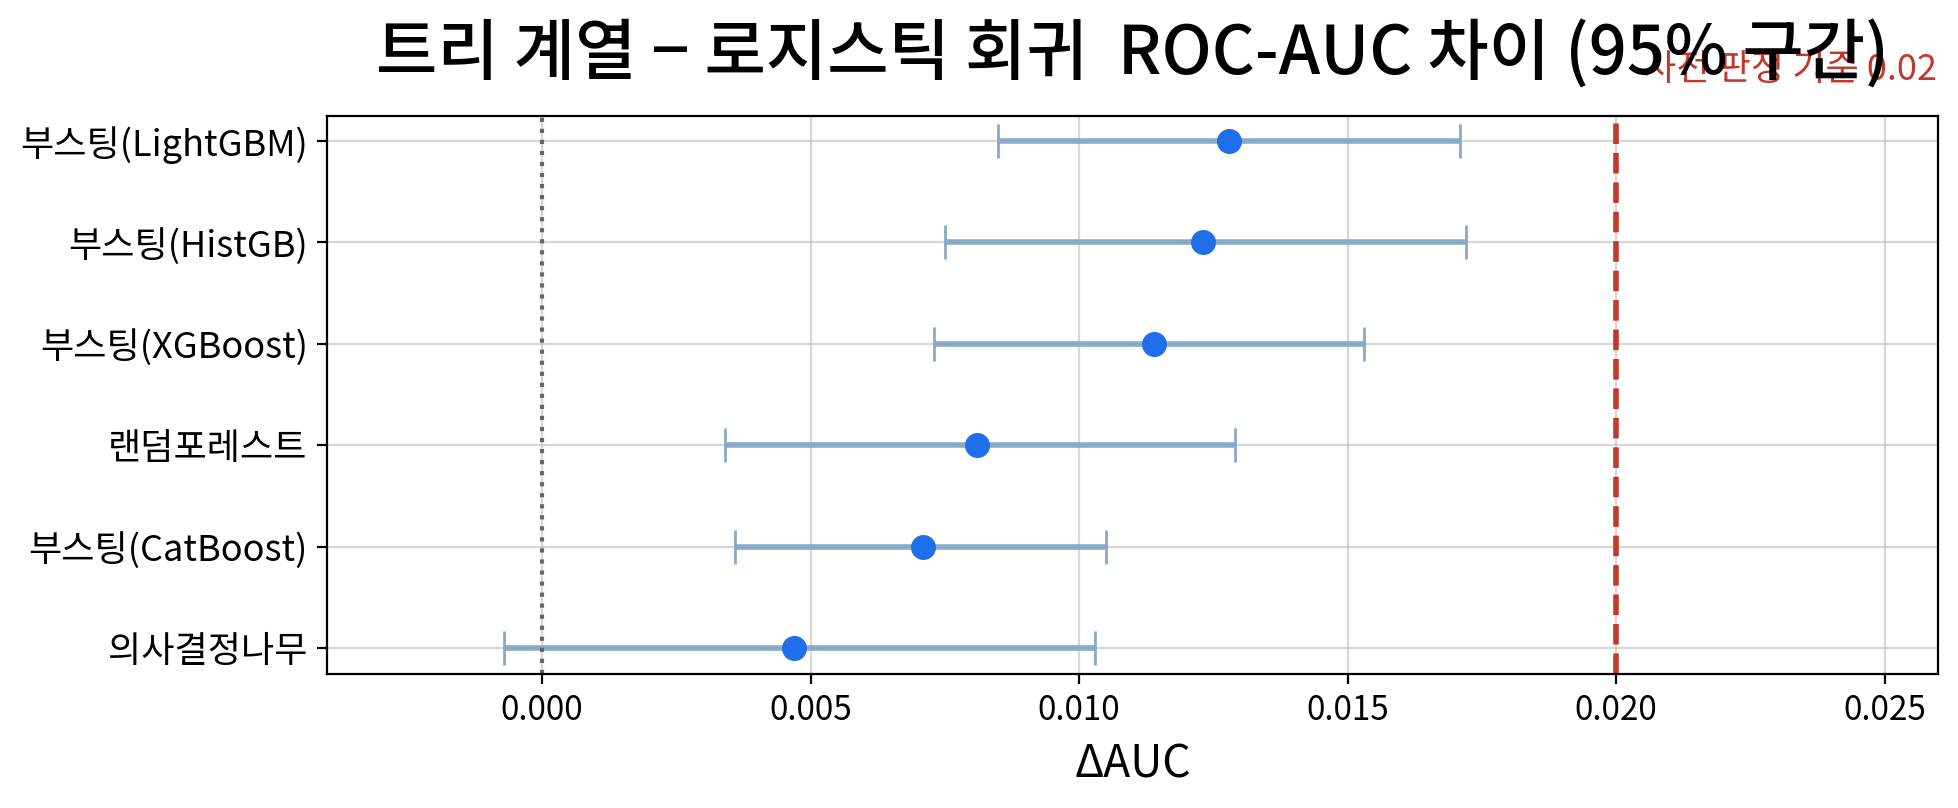

In [7]:
# #06. [그림 5] 트리 계열과의 ΔAUC 비교 ─────────────────
#   출처 : 14e_ΔAUC_구간.csv 를 그대로 옮긴다. 판정선 0.02 는 사전 확정값이다.
e = read_csv(OUT + r"\14e_ΔAUC_구간.csv", encoding="utf-8-sig")
e = e.sort_values("ΔAUC")

fig, ax = my_plot.init(width=1000, height=420,
                       title="트리 계열 − 로지스틱 회귀  ROC-AUC 차이 (95% 구간)",
                       xlabel="ΔAUC")
pos = np.arange(len(e))
lo = e["ΔAUC"] - e["95% 하한"]
hi = e["95% 상한"] - e["ΔAUC"]
ax.errorbar(e["ΔAUC"], pos, xerr=[lo, hi], fmt="o", ms=8, capsize=6,
            color="#1f6feb", ecolor="#8aa9c7", elinewidth=2)
ax.axvline(0,    color="#666",    ls=":",  lw=1.5)
ax.axvline(0.02, color="#c0392b", ls="--", lw=2)
ax.text(0.0205, len(e) - 0.4, "사전 판정 기준 0.02", fontsize=13, color="#c0392b")
ax.set_yticks(pos); ax.set_yticklabels(e["트리"], fontsize=13)
ax.set_xlim(-0.004, 0.026)
save("fig05_트리비교.png")

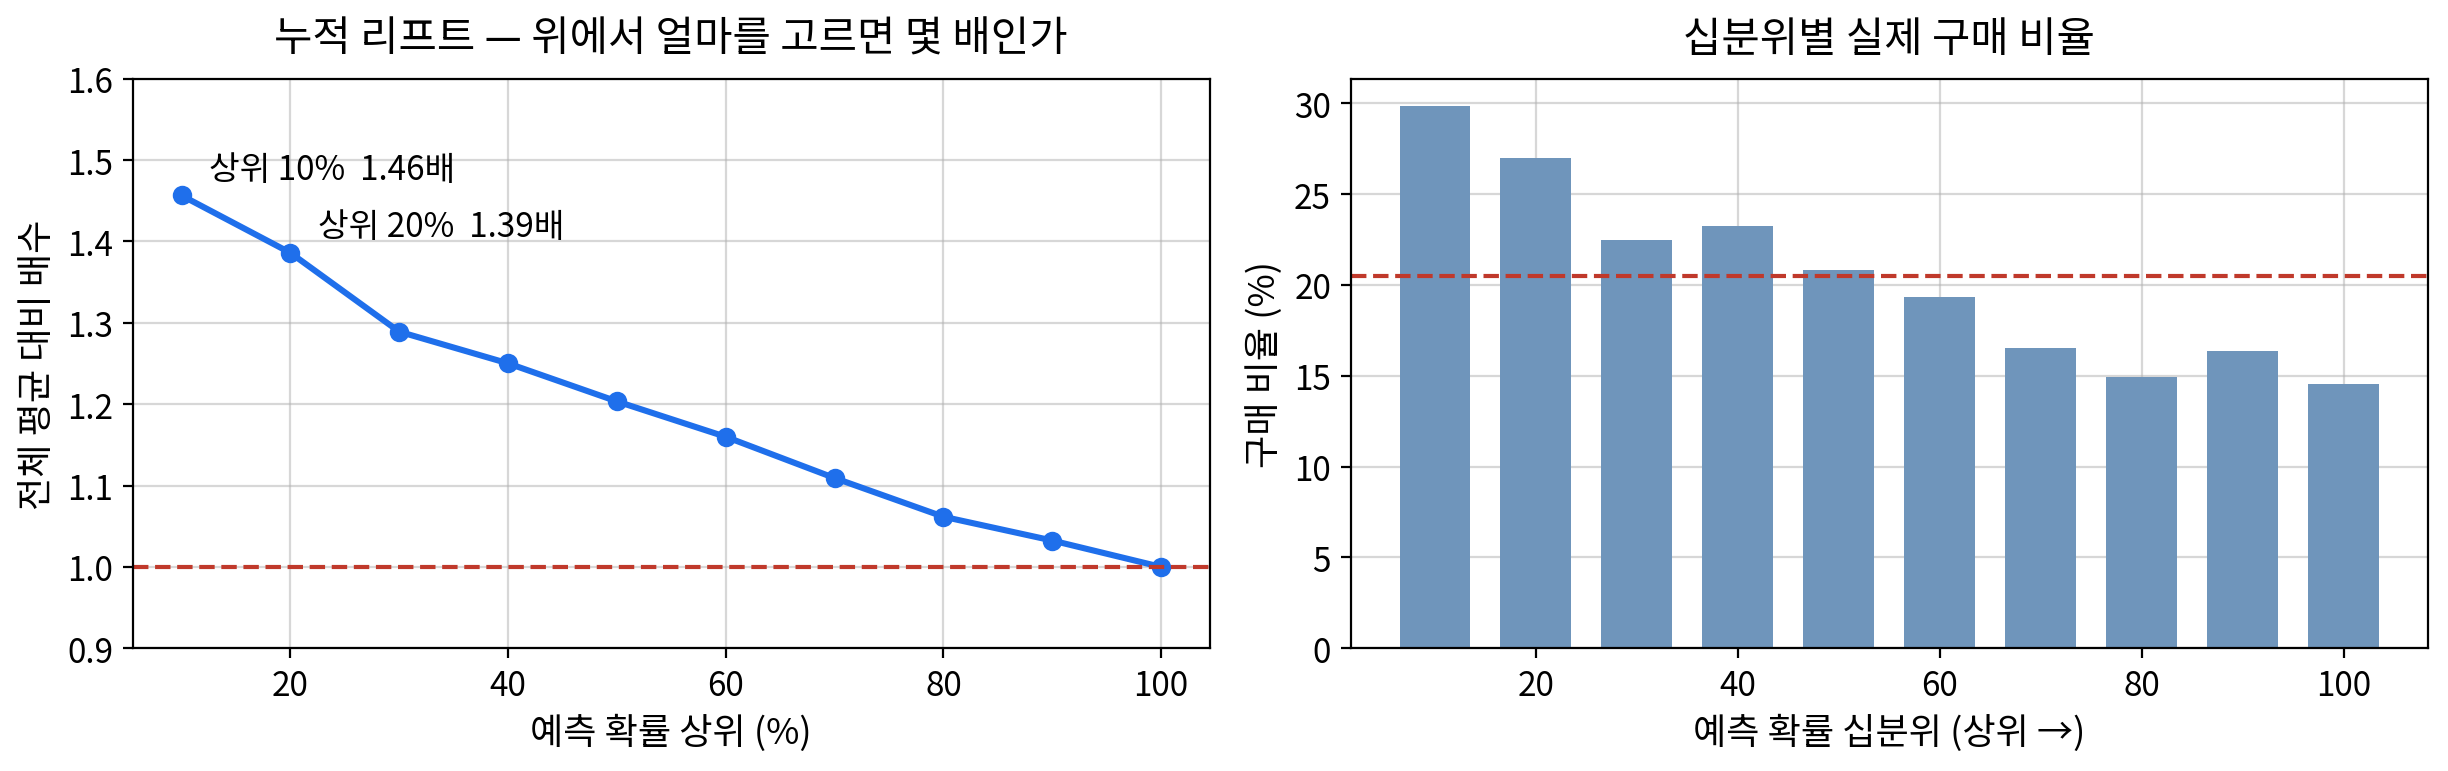

In [8]:
# #07. [그림 6] 누적 리프트와 십분위별 구매 비율 ─────────
#   출처 : 14j_십분위_프로파일.csv. 누적값은 인원·실제양성으로 다시 센다.
j = read_csv(OUT + r"\14j_십분위_프로파일.csv", encoding="utf-8-sig")
cn = j["인원"].cumsum()
cp = j["실제양성"].cumsum()
cum_rate = cp / cn * 100
cum_lift = cum_rate / (m["purchase_7d"].mean() * 100)

fig, ax = my_plot.init(width=620, height=420, rows=1, cols=2)
xs = np.arange(1, len(j) + 1) * 10

ax[0].plot(xs, cum_lift, marker="o", color="#1f6feb", lw=2.2)
ax[0].axhline(1.0, color="#c0392b", ls="--", lw=1.5)
for k in (0, 1):
    ax[0].annotate(f"상위 {xs[k]}%  {cum_lift.iloc[k]:.2f}배",
                   (xs[k], cum_lift.iloc[k]), textcoords="offset points",
                   xytext=(10, 6), fontsize=12)
ax[0].set_title("누적 리프트 — 위에서 얼마를 고르면 몇 배인가", fontsize=15, pad=10)
ax[0].set_xlabel("예측 확률 상위 (%)", fontsize=13)
ax[0].set_ylabel("전체 평균 대비 배수", fontsize=13)
ax[0].set_ylim(0.9, 1.6)

ax[1].bar(xs, j["양성률(%)"], width=7, color="#6f95bb")
ax[1].axhline(m["purchase_7d"].mean() * 100, color="#c0392b", ls="--", lw=1.5)
ax[1].set_title("십분위별 실제 구매 비율", fontsize=15, pad=10)
ax[1].set_xlabel("예측 확률 십분위 (상위 →)", fontsize=13)
ax[1].set_ylabel("구매 비율 (%)", fontsize=13)
save("fig06_리프트.png")

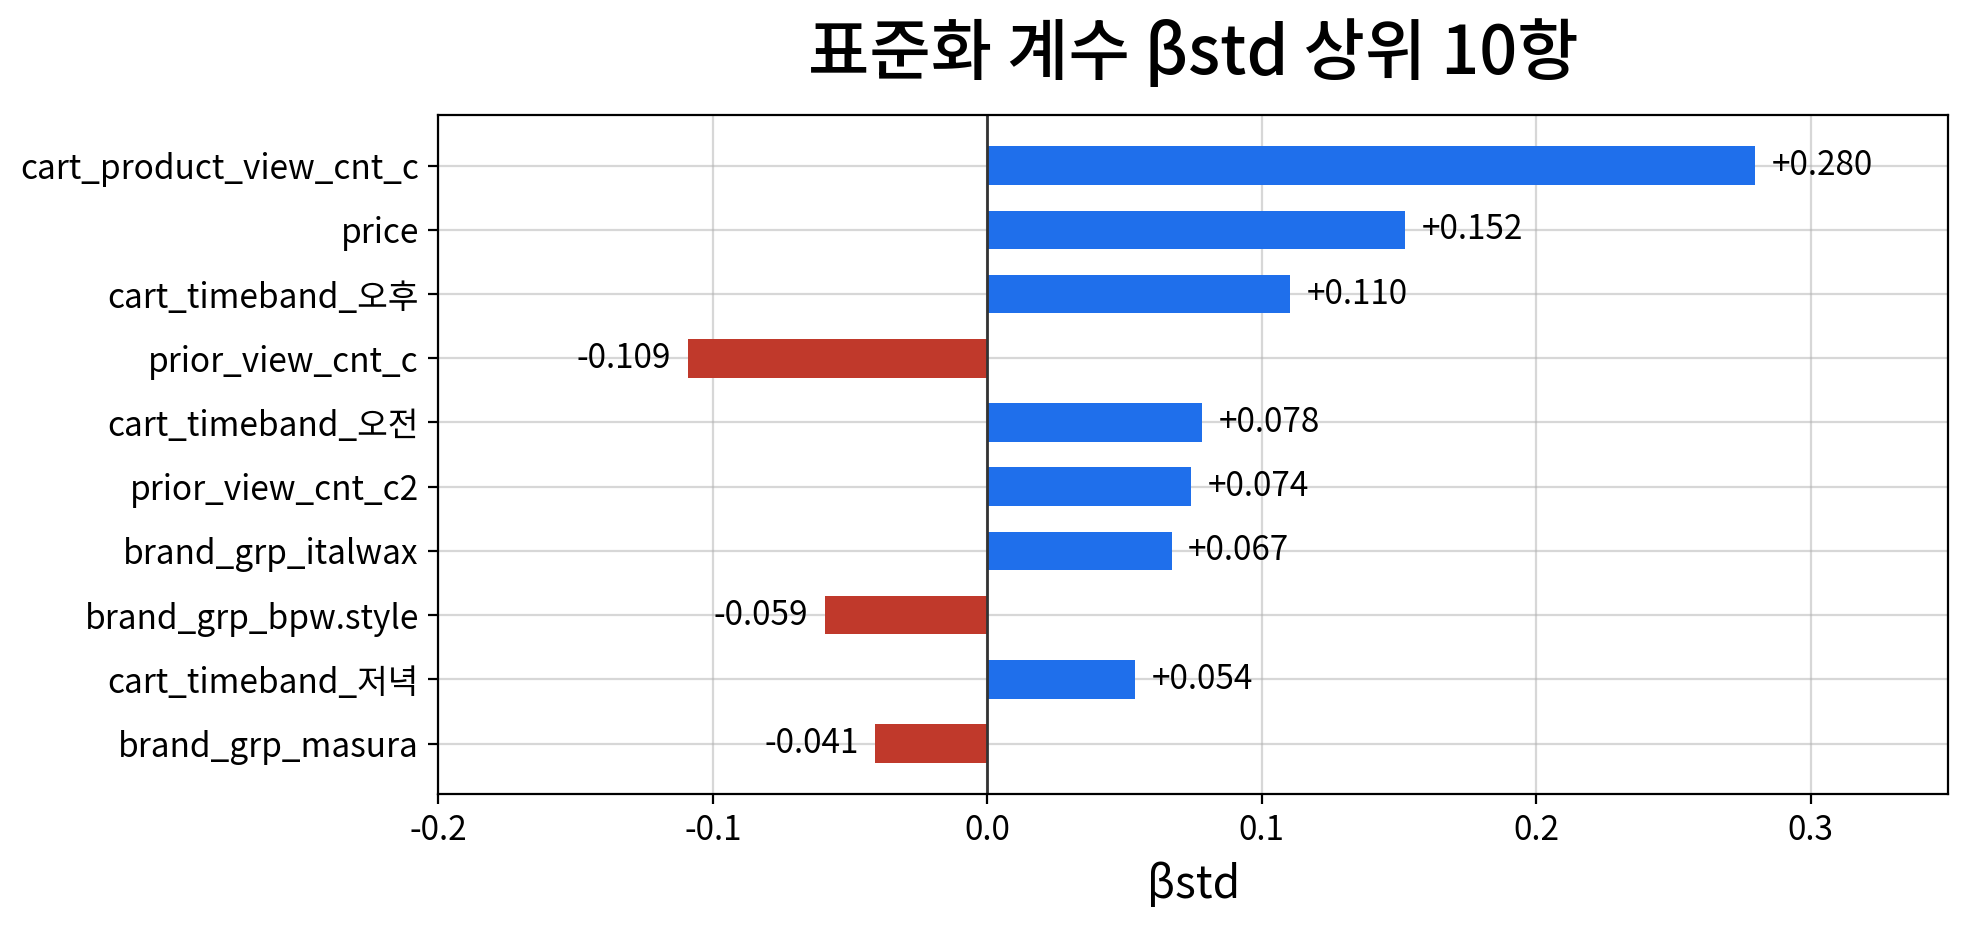

In [9]:
# #08. [그림 7] 표준화 계수 βstd 상위 항 ─────────────────
#   출처 : 14g_영향력순위_βstd.csv 상위 10개.
b = read_csv(OUT + r"\14g_영향력순위_βstd.csv", encoding="utf-8-sig")
b = b.nlargest(10, "절대βstd").sort_values("절대βstd")

fig, ax = my_plot.init(width=1000, height=480,
                       title="표준화 계수 βstd 상위 10항", xlabel="βstd")
col = ["#1f6feb" if v > 0 else "#c0392b" for v in b["βstd"]]
ax.barh(np.arange(len(b)), b["βstd"], color=col, height=0.6)
for i, v in enumerate(b["βstd"]):
    ax.text(v + (0.006 if v > 0 else -0.006), i, f"{v:+.3f}",
            va="center", ha="left" if v > 0 else "right", fontsize=12)
ax.axvline(0, color="#333", lw=1)
ax.set_yticks(np.arange(len(b)))
ax.set_yticklabels(b["독립변수"], fontsize=12)
ax.set_xlim(-0.2, 0.35)
save("fig07_betastd.png")

13f_성능_train_test.csv 의 test·0.19 행과 대조할 것
AUC 0.5841  TN7846 FP9399 FN1480 TP2967


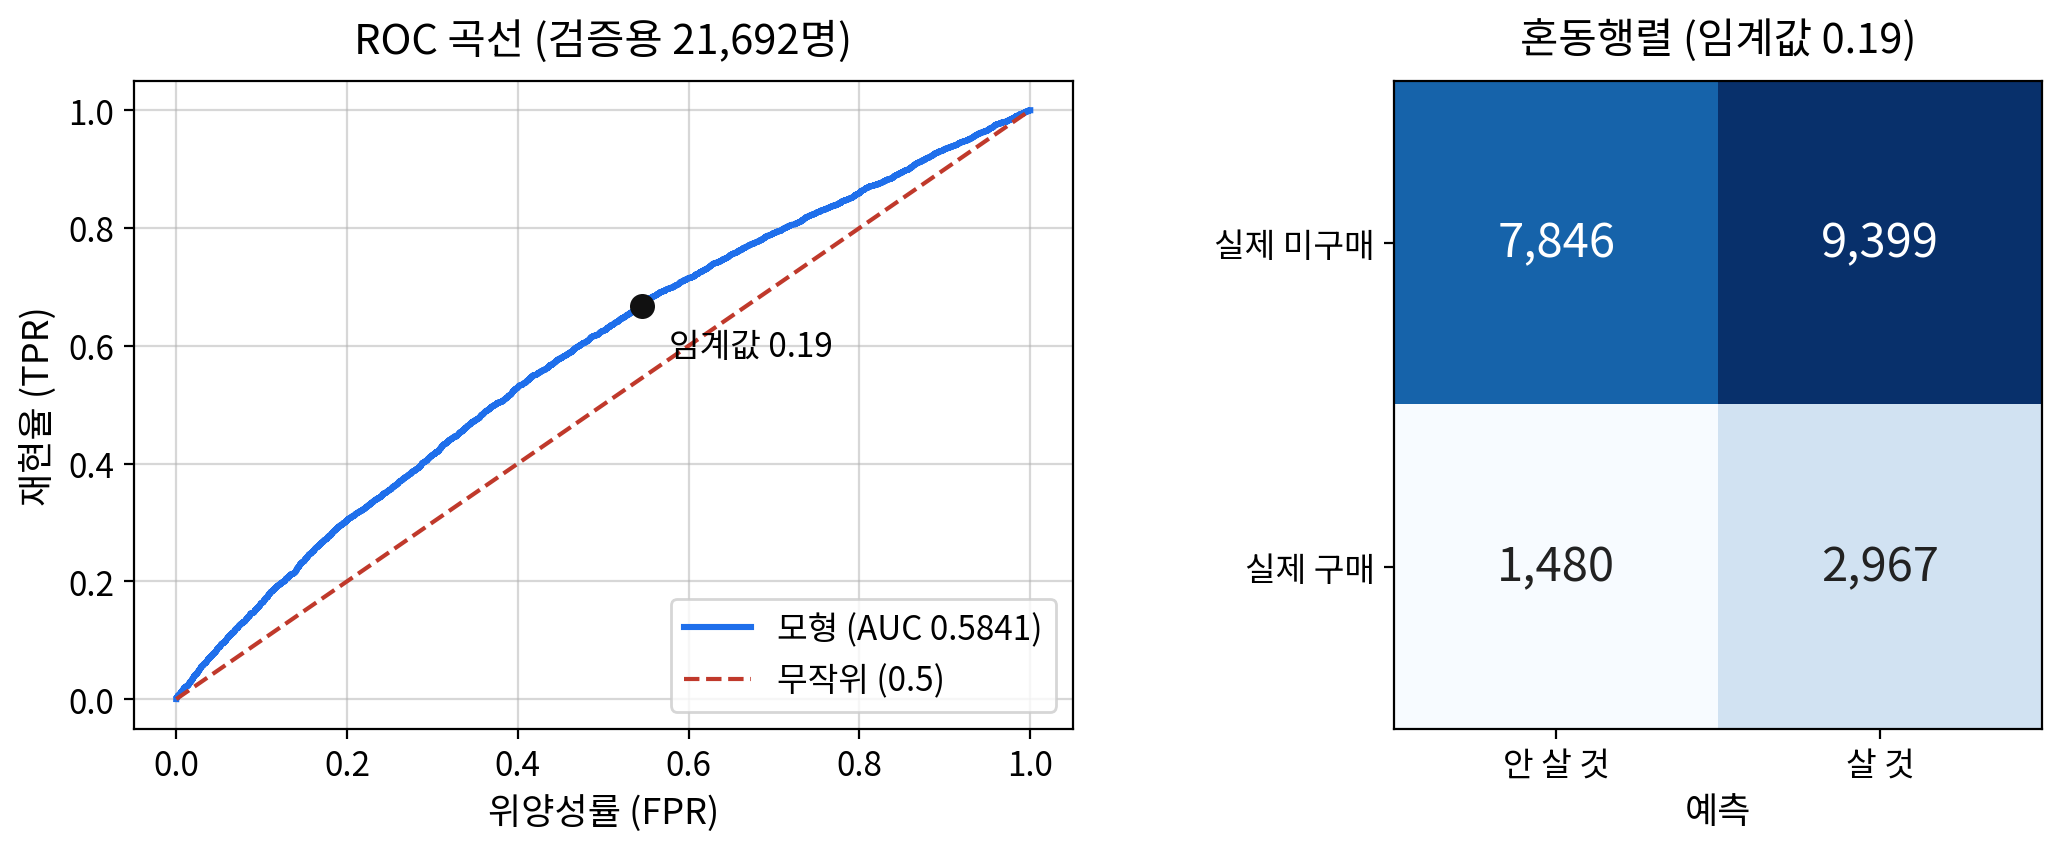

In [10]:
# #09. [그림 8] 검증용 ROC 곡선과 혼동행렬 (임계값 0.19) ──
#   13번 #36 의 report_performance 그림은 train·임계 0.5 기준이라 보고서에 쓸 수 없다.
#   여기서 test·임계 0.19 로 다시 그린다. 예측값은 13j 를 그대로 읽는다.
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix

p = read_csv(OUT + r"\13j_예측_test.csv", encoding="utf-8-sig")
THR = 0.19
fpr, tpr, _ = roc_curve(p["y_true"], p["proba"])
auc = roc_auc_score(p["y_true"], p["proba"])
pred = (p["proba"] > THR).astype(int)
cm = confusion_matrix(p["y_true"], pred)
print("13f_성능_train_test.csv 의 test·0.19 행과 대조할 것")
print(f"AUC {auc:.4f}  TN{cm[0,0]} FP{cm[0,1]} FN{cm[1,0]} TP{cm[1,1]}")

fig, ax = my_plot.init(width=560, height=460, rows=1, cols=2)
ax[0].plot(fpr, tpr, color="#1f6feb", lw=2.2, label=f"모형 (AUC {auc:.4f})")
ax[0].plot([0, 1], [0, 1], ls="--", color="#c0392b", lw=1.5, label="무작위 (0.5)")
fp_at = ((p["proba"] > THR) & (p["y_true"] == 0)).sum() / (p["y_true"] == 0).sum()
tp_at = ((p["proba"] > THR) & (p["y_true"] == 1)).sum() / (p["y_true"] == 1).sum()
ax[0].plot([fp_at], [tp_at], "o", color="#111", ms=8)
ax[0].annotate(f"임계값 {THR}", (fp_at, tp_at), textcoords="offset points",
               xytext=(10, -18), fontsize=12)
ax[0].set_title("ROC 곡선 (검증용 21,692명)", fontsize=15, pad=10)
ax[0].set_xlabel("위양성률 (FPR)", fontsize=13)
ax[0].set_ylabel("재현율 (TPR)", fontsize=13)
ax[0].legend(fontsize=12, loc="lower right")

ax[1].imshow(cm, cmap="Blues")
for r in range(2):
    for c in range(2):
        ax[1].text(c, r, f"{cm[r, c]:,}", ha="center", va="center", fontsize=17,
                   color="w" if cm[r, c] > cm.max() / 2 else "#222")
ax[1].set_title(f"혼동행렬 (임계값 {THR})", fontsize=15, pad=10)
ax[1].set_xticks([0, 1]); ax[1].set_xticklabels(["안 살 것", "살 것"], fontsize=12)
ax[1].set_yticks([0, 1]); ax[1].set_yticklabels(["실제 미구매", "실제 구매"], fontsize=12)
ax[1].set_xlabel("예측", fontsize=13); ax[1].grid(False)
save("fig08_ROC_혼동행렬.png")

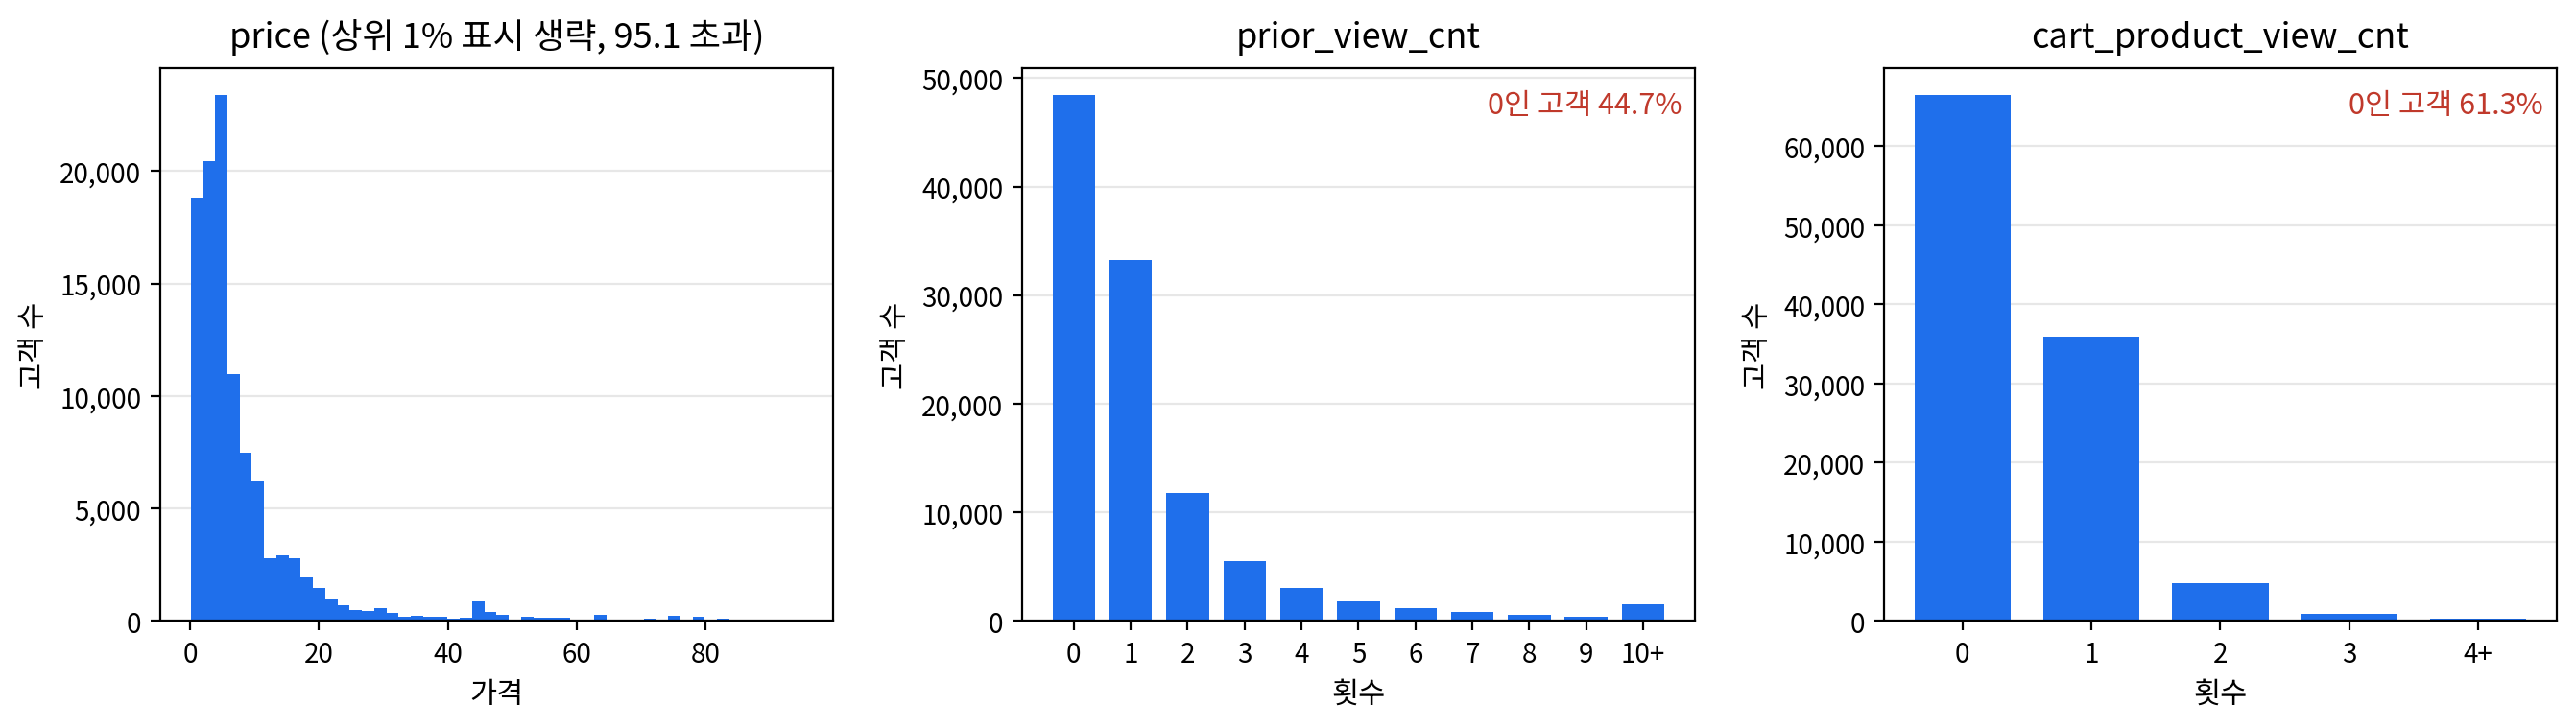

price 99분위 95.08  |  최대 327.78
prior_view_cnt 0 비율 44.68%  |  10+ 1,538명
cart_product_view_cnt 0 비율 61.30%  |  4+ 311명


In [11]:
# #10. [그림 9] 연속형 세 변수의 단변량 분포 ─────────────────
#   출처 : 마스터 테이블 price · prior_view_cnt · cart_product_view_cnt (108,458명)
#   슬라이드 p.15 그림 틀 비율(3.37 : 1)에 맞춰 뽑는다.
#   → 공통 save()의 bbox_inches="tight"는 비율을 바꾸므로 여기서는 쓰지 않는다.
BLUE, RED = "#1f6feb", "#c0392b"

price = m["price"]
p99   = price.quantile(0.99)
pv    = m["prior_view_cnt"].clip(upper=10)          # 10회 이상 → 10+
cv    = m["cart_product_view_cnt"].clip(upper=4)    # 4회 이상 → 4+

fig, ax = plt.subplots(1, 3, figsize=(13.5, 4.0), dpi=200)

# ① price — 상위 1%는 표시만 생략(데이터에서 빼지 않는다)
ax[0].hist(price[price <= p99], bins=50, color=BLUE)
ax[0].set_title(f"price (상위 1% 표시 생략, {p99:,.1f} 초과)", fontsize=13, pad=8)
ax[0].set_xlabel("가격", fontsize=11)

# ② prior_view_cnt / ③ cart_product_view_cnt — 막대
for a, s, cap, name in [(ax[1], pv, 10, "prior_view_cnt"),
                        (ax[2], cv, 4,  "cart_product_view_cnt")]:
    cnt = s.value_counts().reindex(range(cap + 1), fill_value=0)
    a.bar(cnt.index, cnt.values, color=BLUE, width=0.75)
    a.set_xticks(range(cap + 1))
    a.set_xticklabels([str(i) for i in range(cap)] + [f"{cap}+"])
    a.set_title(name, fontsize=13, pad=8)
    a.set_xlabel("횟수", fontsize=11)
    zero = (s == 0).mean() * 100
    a.text(0.98, 0.96, f"0인 고객 {zero:.1f}%", transform=a.transAxes,
           ha="right", va="top", fontsize=11, color=RED)

for a in ax:
    a.set_ylabel("고객 수", fontsize=11)
    a.tick_params(labelsize=10)
    a.grid(axis="y", alpha=0.3)
    a.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:,.0f}"))

# 가장자리 여백을 직접 잡는다 — 축 숫자·제목이 잘리지 않게
fig.subplots_adjust(left=0.065, right=0.99, top=0.88, bottom=0.16, wspace=0.28)
fig.savefig(os.path.join(FIG, "fig05_단변량분포_v2.png"), dpi=200, facecolor="white")
plt.show(); plt.close()

# 검산 — 브리핑 수치(0 비율 44.68% · 61.31%)와 대조
print(f"price 99분위 {p99:,.2f}  |  최대 {price.max():,.2f}")
print(f"prior_view_cnt 0 비율 {(m['prior_view_cnt']==0).mean():.2%}  |  10+ {(m['prior_view_cnt']>=10).sum():,}명")
print(f"cart_product_view_cnt 0 비율 {(m['cart_product_view_cnt']==0).mean():.2%}  |  4+ {(m['cart_product_view_cnt']>=4).sum():,}명")